In [26]:
from charts.common.redis import request_redis
from datetime import datetime

# js query on https://en.wikipedia.org/wiki/2026_FIFA_World_Cup
# JSON.stringify(
#     [...new Set(
#         [...document.querySelectorAll(".fgoals a")]
#             .map(a => a.href.replace("https://en.wikipedia.org/wiki/", ""))
#             .filter(h => !h.includes("cite") && !h.includes("ssociation"))
#     )]
# )

domain = "en.wikipedia"
start = "2026060100"
end = "2026062500"
headers = {
    "Accept": "application/json",
    "User-Agent": "charts/0.1 (github.com/theraphael0000) requests"
}

def query(player):
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{domain}/all-access/user/{player}/daily/{start}/{end}"
    r = request_redis(url, headers=headers)
    return parse_stats(r)


def parse_stats(stats):
    return [(datetime.strptime(d["timestamp"], "%Y%m%d%H"), d["views"]) for d in stats["items"]]

In [27]:
import json

players = json.load(open("players.json"))

stats = {}

for p in players:
    p_stats = query(p)
    stats[p] = p_stats

In [28]:
top = sorted(stats.keys(), key=lambda p: -sum([*zip(*stats[p])][-1]))
print(top)

['Lionel_Messi', 'Cristiano_Ronaldo', 'Kylian_Mbapp%C3%A9', 'Erling_Haaland', 'Folarin_Balogun', 'Lamine_Yamal', 'Deniz_Undav', 'Harry_Kane', 'Juli%C3%A1n_Qui%C3%B1ones', 'Yasin_Ayari', 'Jude_Bellingham', 'Nestory_Irankunda', 'Giovanni_Reyna', 'Ra%C3%BAl_Jim%C3%A9nez', 'Mohamed_Salah', 'Jonathan_David', 'Vin%C3%ADcius_J%C3%BAnior', 'Ousmane_Demb%C3%A9l%C3%A9', 'Achraf_Hakimi', 'Nathaniel_Brown_(footballer)', 'Alex_Freeman', 'Felix_Nmecha', 'Crysencio_Summerville', 'Elijah_Just', 'Ismael_Saibari', 'Marcus_Rashford', 'Brian_Brobbey', 'Jamal_Musiala', 'Mikel_Oyarzabal', 'Virgil_van_Dijk', 'Cyle_Larin', 'Alexander_Isak', 'Kai_Havertz', 'Granit_Xhaka', 'Jo%C3%A3o_Neves', 'Matheus_Cunha', 'Johan_Manzambi', 'John_McGinn', 'Viktor_Gy%C3%B6keres', 'Jovo_Luki%C4%87', 'Bradley_Barcola', 'Leroy_San%C3%A9', 'Arda_G%C3%BCler', 'Breel_Embolo', 'Anthony_Elanga', 'Petar_Musa', 'Yassine_Bounou', 'Promise_David', 'Cody_Gakpo', 'Keito_Nakamura', 'Franck_Kessi%C3%A9', 'Yoane_Wissa', 'Marko_Arnautovi%C4%87'

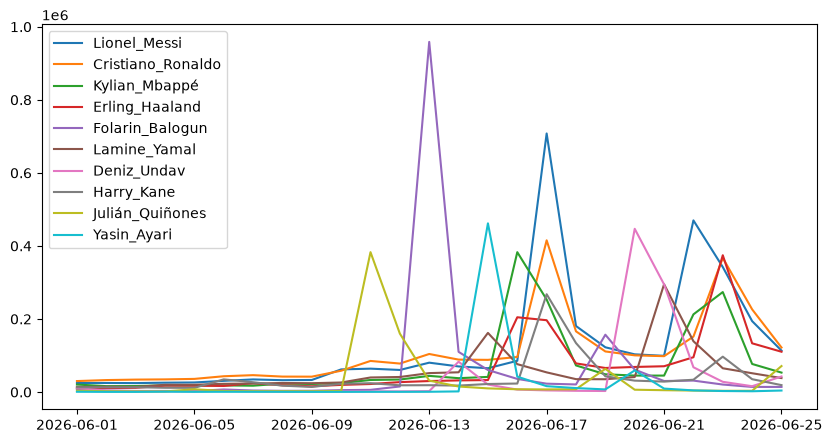

In [35]:
import matplotlib.pyplot as plt
import urllib



plt.figure(figsize=(10,5))
for p in top[0:10]:
    s = stats[p]
    X,Y = zip(*s)
    
    plt.plot(X,Y, label=urllib.parse.unquote(p))

plt.legend()

plt.show()